In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/object-counting/dataset/README.dataset.txt
/kaggle/input/object-counting/dataset/README.roboflow.txt
/kaggle/input/object-counting/dataset/data.yaml
/kaggle/input/object-counting/dataset/valid/labels.cache
/kaggle/input/object-counting/dataset/valid/labels/images-2023-11-28T175716-530_jpg.rf.42b974b3f7c4c7302f3e58bd39599033.txt
/kaggle/input/object-counting/dataset/valid/labels/-_image_109_jpg.rf.2872a85f6bef1b558327c21637fb9a4a.txt
/kaggle/input/object-counting/dataset/valid/labels/images-52-_jpg.rf.bfdaf603b9bc4d94462899f616d08926.txt
/kaggle/input/object-counting/dataset/valid/labels/images-2023-11-28T175738-102_jpg.rf.36ebdb7e607fbdc1bc2d62ca854be1a7.txt
/kaggle/input/object-counting/dataset/valid/labels/-2024-08-05T172623-296_jpg.rf.a6991acdf1b9cbcbcdafc2841dadd447.txt
/kaggle/input/object-counting/dataset/valid/labels/10-reinforced-boxes-25x18x14-cm_jpg.rf.c7e40e1a568daeeb27c50e210768f3ec.txt
/kaggle/input/object-counting/dataset/valid/labels/professionele-Verhuisdo

# 0. Import Library

In [2]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 25.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 84.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 69.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 43.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 28.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 12.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 65.3 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling

In [3]:
import numpy as np
import pandas as pd
import os
import yaml
import glob
from PIL import Image as PILImage
import shutil
import torch
import cv2
import random
import matplotlib.pyplot as plt
import seaborn as sns
from ultralytics import YOLO
from pathlib import Path
from IPython.display import display, Image

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [4]:
def check_device():
    return 'cuda' if torch.cuda.is_available() else 'cpu'
    
def load_yaml(yaml_path):
    with open(yaml_path, 'r') as f:
        return yaml.safe_load(f)

# 1. Data Loading

In [5]:
data_config = {
    'train': '/kaggle/input/object-counting/dataset/train',
    'val': '/kaggle/input/object-counting/dataset/valid',
    'test': '/kaggle/input/object-counting/dataset/test',
    'nc': 2,
    'names': ['bag', 'box']  # Ganti sesuai dengan nama kelasmu
}


In [6]:
yaml_path = '/kaggle/working/data.yaml'
with open(yaml_path, 'w') as f:
    yaml.dump(data_config, f)


## Sample Images

In [7]:
def display_sample_images(image_dir, label_dir, class_names, num_samples=4):
    image_files = [f for f in os.listdir(image_dir) if f.endswith(('.jpg', '.jpeg', '.png'))]
    sample_images = random.sample(image_files, min(num_samples, len(image_files)))
    
    plt.figure(figsize=(12, 12))
    for i, image_name in enumerate(sample_images):
        image_path = os.path.join(image_dir, image_name)
        label_path = os.path.join(label_dir, os.path.splitext(image_name)[0] + '.txt')
        
        image = cv2.imread(image_path)
        h, w, _ = image.shape
        
        if os.path.exists(label_path):
            with open(label_path, 'r') as f:
                for line in f.readlines():
                    class_id, x_center, y_center, width, height = map(float, line.split())
                    
                    x1 = int((x_center - width / 2) * w)
                    y1 = int((y_center - height / 2) * h)
                    x2 = int((x_center + width / 2) * w)
                    y2 = int((y_center + height / 2) * h)
                    
                    # Gambar bounding box
                    cv2.rectangle(image, (x1, y1), (x2, y2), (0, 255, 0), 2)
                    # Tambahkan label kelas
                    label = class_names[int(class_id)]
                    cv2.putText(image, label, (x1, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0, 255, 0), 2)

        ax = plt.subplot(2, 2, i + 1)
        plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
        plt.title(image_name)
        plt.axis('off')
    plt.tight_layout()
    plt.show()

# Tampilkan sampel
train_image_dir = data_config['train']
train_label_dir = train_image_dir.replace('images', 'labels')
display_sample_images(train_image_dir, train_label_dir, data_config['names'])

<Figure size 1200x1200 with 0 Axes>

# 2. Train model

In [8]:
# Memuat model YOLO12m pre-trained
device = check_device()
model = YOLO("yolo12m.pt").to(device)

# Melatih model
results = model.train(
    data=yaml_path, 
    epochs=50,
    imgsz=640, 
    project='YOLO12m-Detection', 
    name='train_results'
)

100%|██████████| 39.0M/39.0M [00:00<00:00, 132MB/s]


engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo12m.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train_results, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plots=True, pose=12.0, pretrained=True, profile=False, project=YOLO12m-Detection, rect=False, resume=False, ret

100%|██████████| 755k/755k [00:00<00:00, 23.5MB/s]


Overriding model.yaml nc=80 with nc=2

                   from  n    params  module                                       arguments                     
  0                  -1  1      1856  ultralytics.nn.modules.conv.Conv             [3, 64, 3, 2]                 
  1                  -1  1     73984  ultralytics.nn.modules.conv.Conv             [64, 128, 3, 2]               
  2                  -1  1    111872  ultralytics.nn.modules.block.C3k2            [128, 256, 1, True, 0.25]     
  3                  -1  1    590336  ultralytics.nn.modules.conv.Conv             [256, 256, 3, 2]              
  4                  -1  1    444928  ultralytics.nn.modules.block.C3k2            [256, 512, 1, True, 0.25]     
  5                  -1  1   2360320  ultralytics.nn.modules.conv.Conv             [512, 512, 3, 2]              
  6                  -1  2   2689536  ultralytics.nn.modules.block.A2C2f           [512, 512, 2, True, 4]        
  7                  -1  1   2360320  ultralytics

100%|██████████| 5.35M/5.35M [00:00<00:00, 101MB/s]


...

      50/50      11.6G     0.4658     0.4543      1.027          5        640: 100%|██████████| 51/51 [00:47<00:00,  1.08it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 3/3 [00:01<00:00,  2.24it/s]

                   all         75        190      0.927      0.903      0.948      0.783



50 epochs completed in 0.698 hours.
Optimizer stripped from YOLO12m-Detection/train_results/weights/last.pt, 40.8MB
Optimizer stripped from YOLO12m-Detection/train_results/weights/best.pt, 40.8MB

Validating YOLO12m-Detection/train_results/weights/best.pt...
Ultralytics 8.3.170 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla P100-PCIE-16GB, 16269MiB)
YOLOv12m summary (fused): 169 layers, 20,106,454 parameters, 0 gradients, 67.1 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 3/3 [00:02<00:00,  1.38it/s]
/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1
/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1


                   all         75        190      0.962      0.877      0.956      0.798
                   bag         17         27      0.986      0.926      0.983       0.84
                   box         57        163      0.938      0.828      0.928      0.756
Speed: 0.2ms preprocess, 15.8ms inference, 0.0ms loss, 3.1ms postprocess per image
Results saved to YOLO12m-Detection/train_results


# 3. Evaluation

In [9]:
metrics = model.val()

Ultralytics 8.3.170 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla P100-PCIE-16GB, 16269MiB)
YOLOv12m summary (fused): 169 layers, 20,106,454 parameters, 0 gradients, 67.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 48.0±24.3 MB/s, size: 29.9 KB)


val: Scanning /kaggle/input/object-counting/dataset/valid/labels... 75 images, 1 backgrounds, 0 corrupt: 100%|██████████| 75/75 [00:00<00:00, 1019.00it/s]

WARNING ⚠️ val: Cache directory /kaggle/input/object-counting/dataset/valid is not writeable, cache not saved.



                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 5/5 [00:02<00:00,  2.10it/s]
/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1
/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1


                   all         75        190      0.962       0.88      0.956        0.8
                   bag         17         27      0.985      0.926      0.983      0.843
                   box         57        163      0.938      0.835      0.928      0.757
Speed: 4.1ms preprocess, 17.6ms inference, 0.0ms loss, 2.0ms postprocess per image
Results saved to YOLO12m-Detection/train_results2


In [10]:
map_50 = metrics.box.map50
map_50_95 = metrics.box.map
precision = metrics.box.mp
recall = metrics.box.mr

print(f"mAP@0.5: {map_50:.2%}")
print(f"mAP@0.5:0.95: {map_50_95:.2%}")
print(f"Precision: {precision:.2%}")
print(f"Recall: {recall:.2%}")

mAP@0.5: 95.57%
mAP@0.5:0.95: 80.03%
Precision: 96.17%
Recall: 88.04%


# 4. Visualizing Results

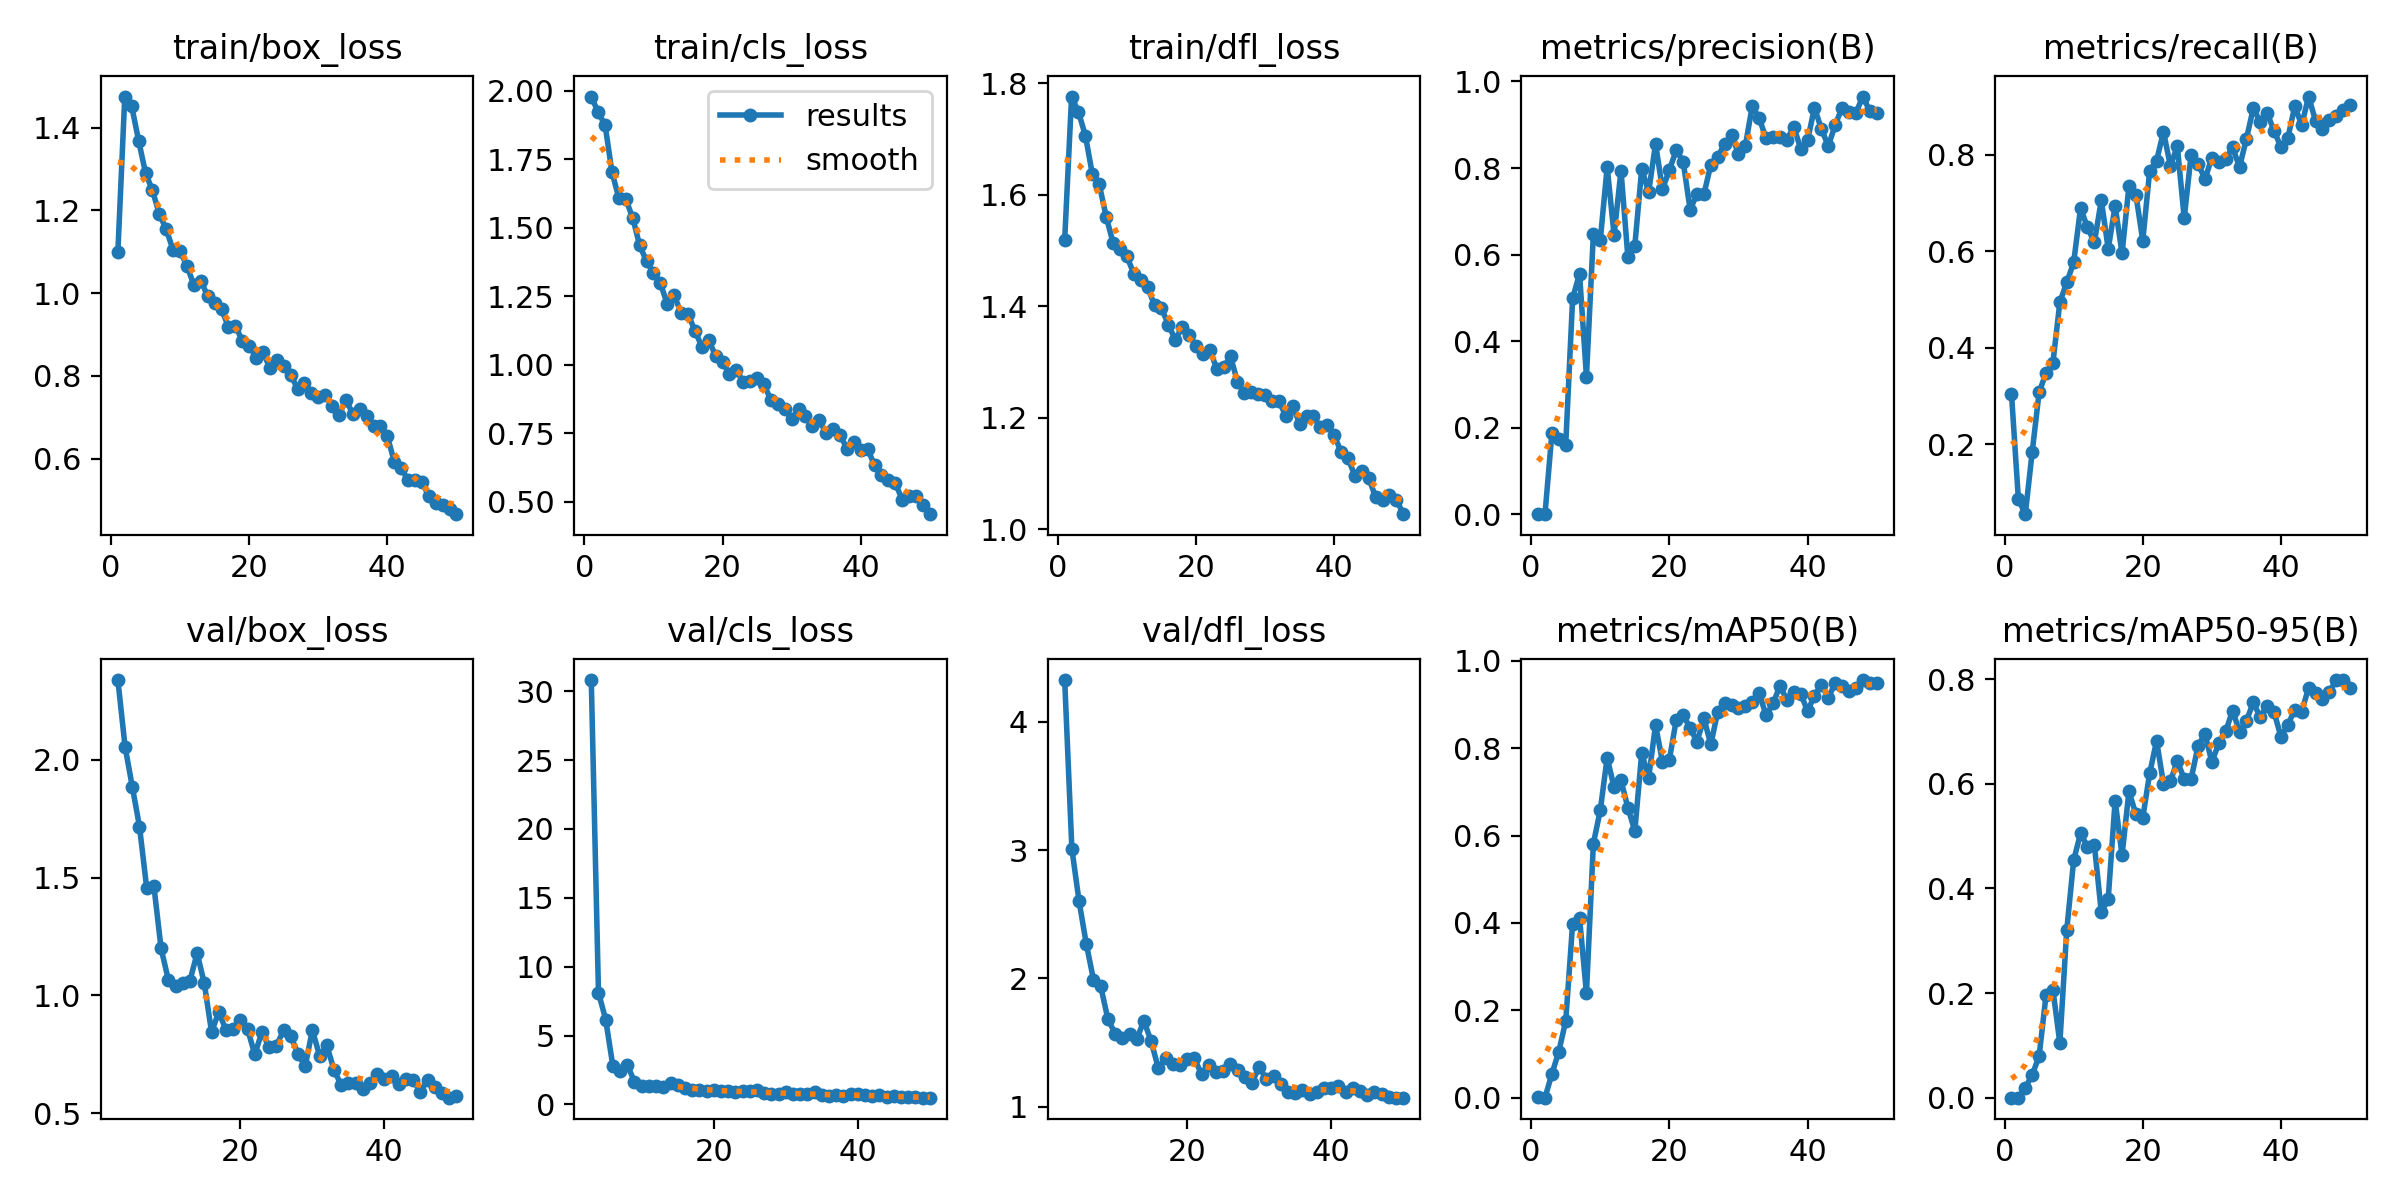

In [11]:
display(Image(filename='YOLO12m-Detection/train_results/results.png'))

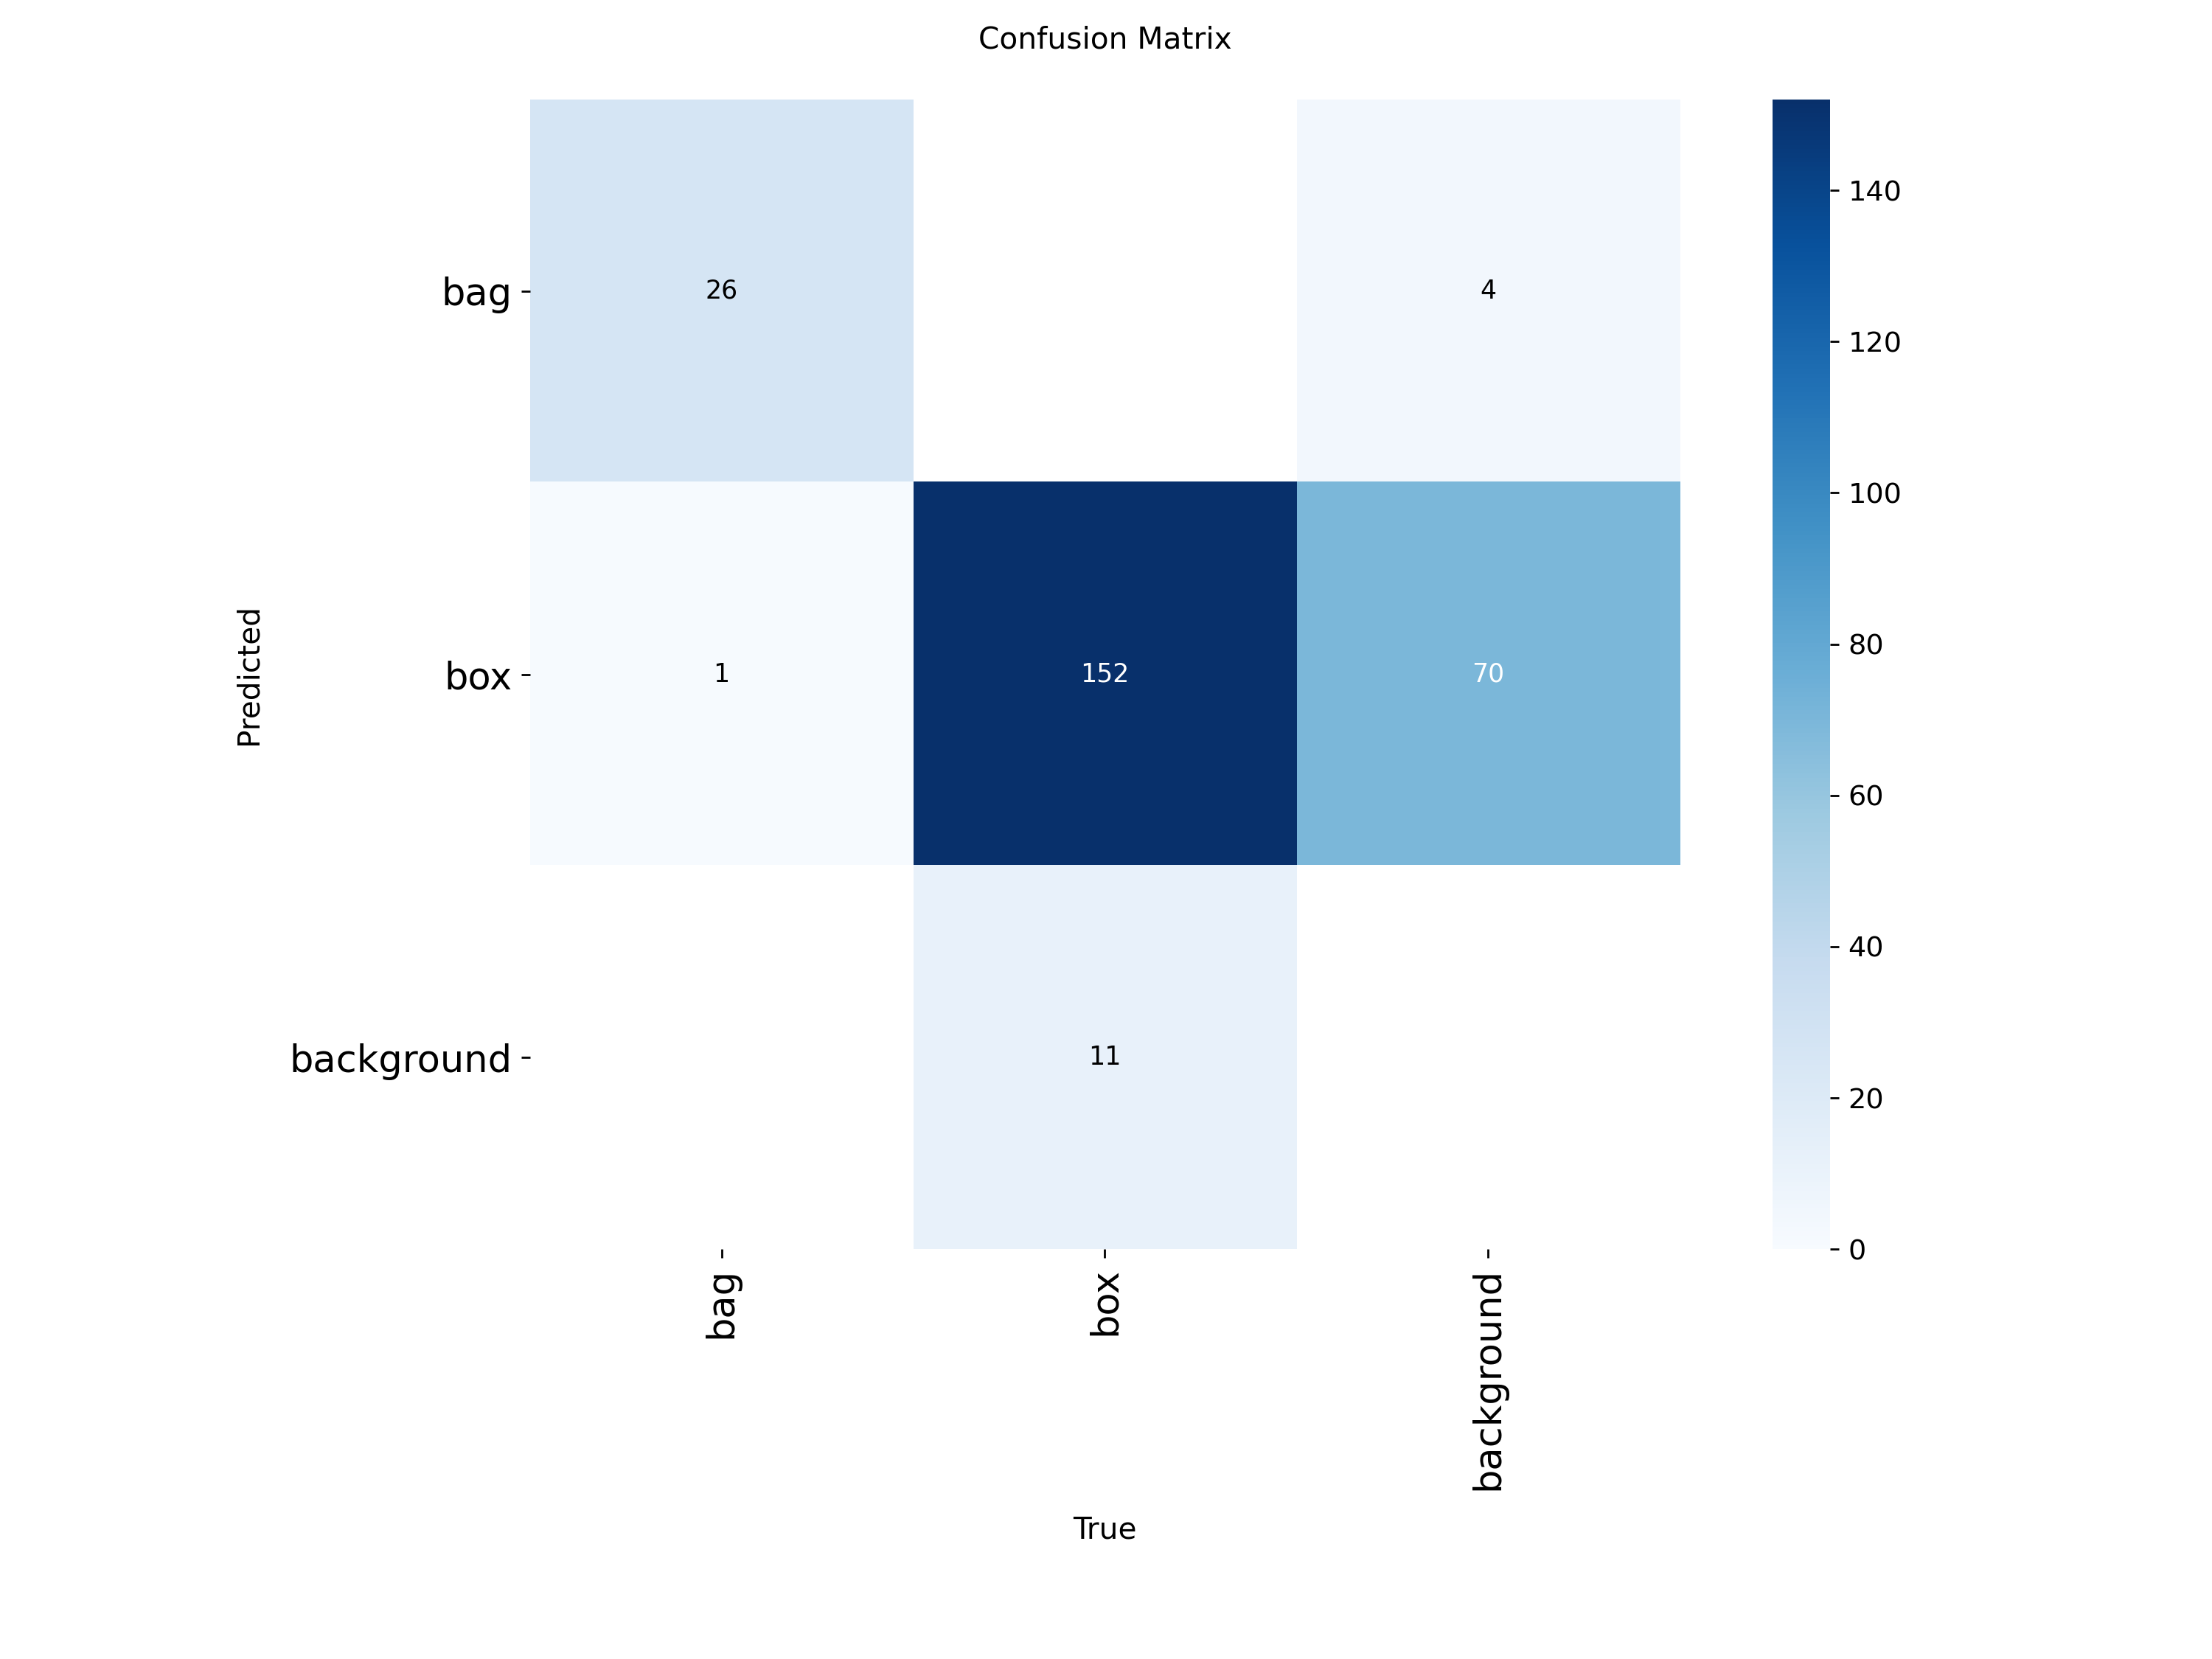

In [12]:
display(Image(filename='YOLO12m-Detection/train_results/confusion_matrix.png'))

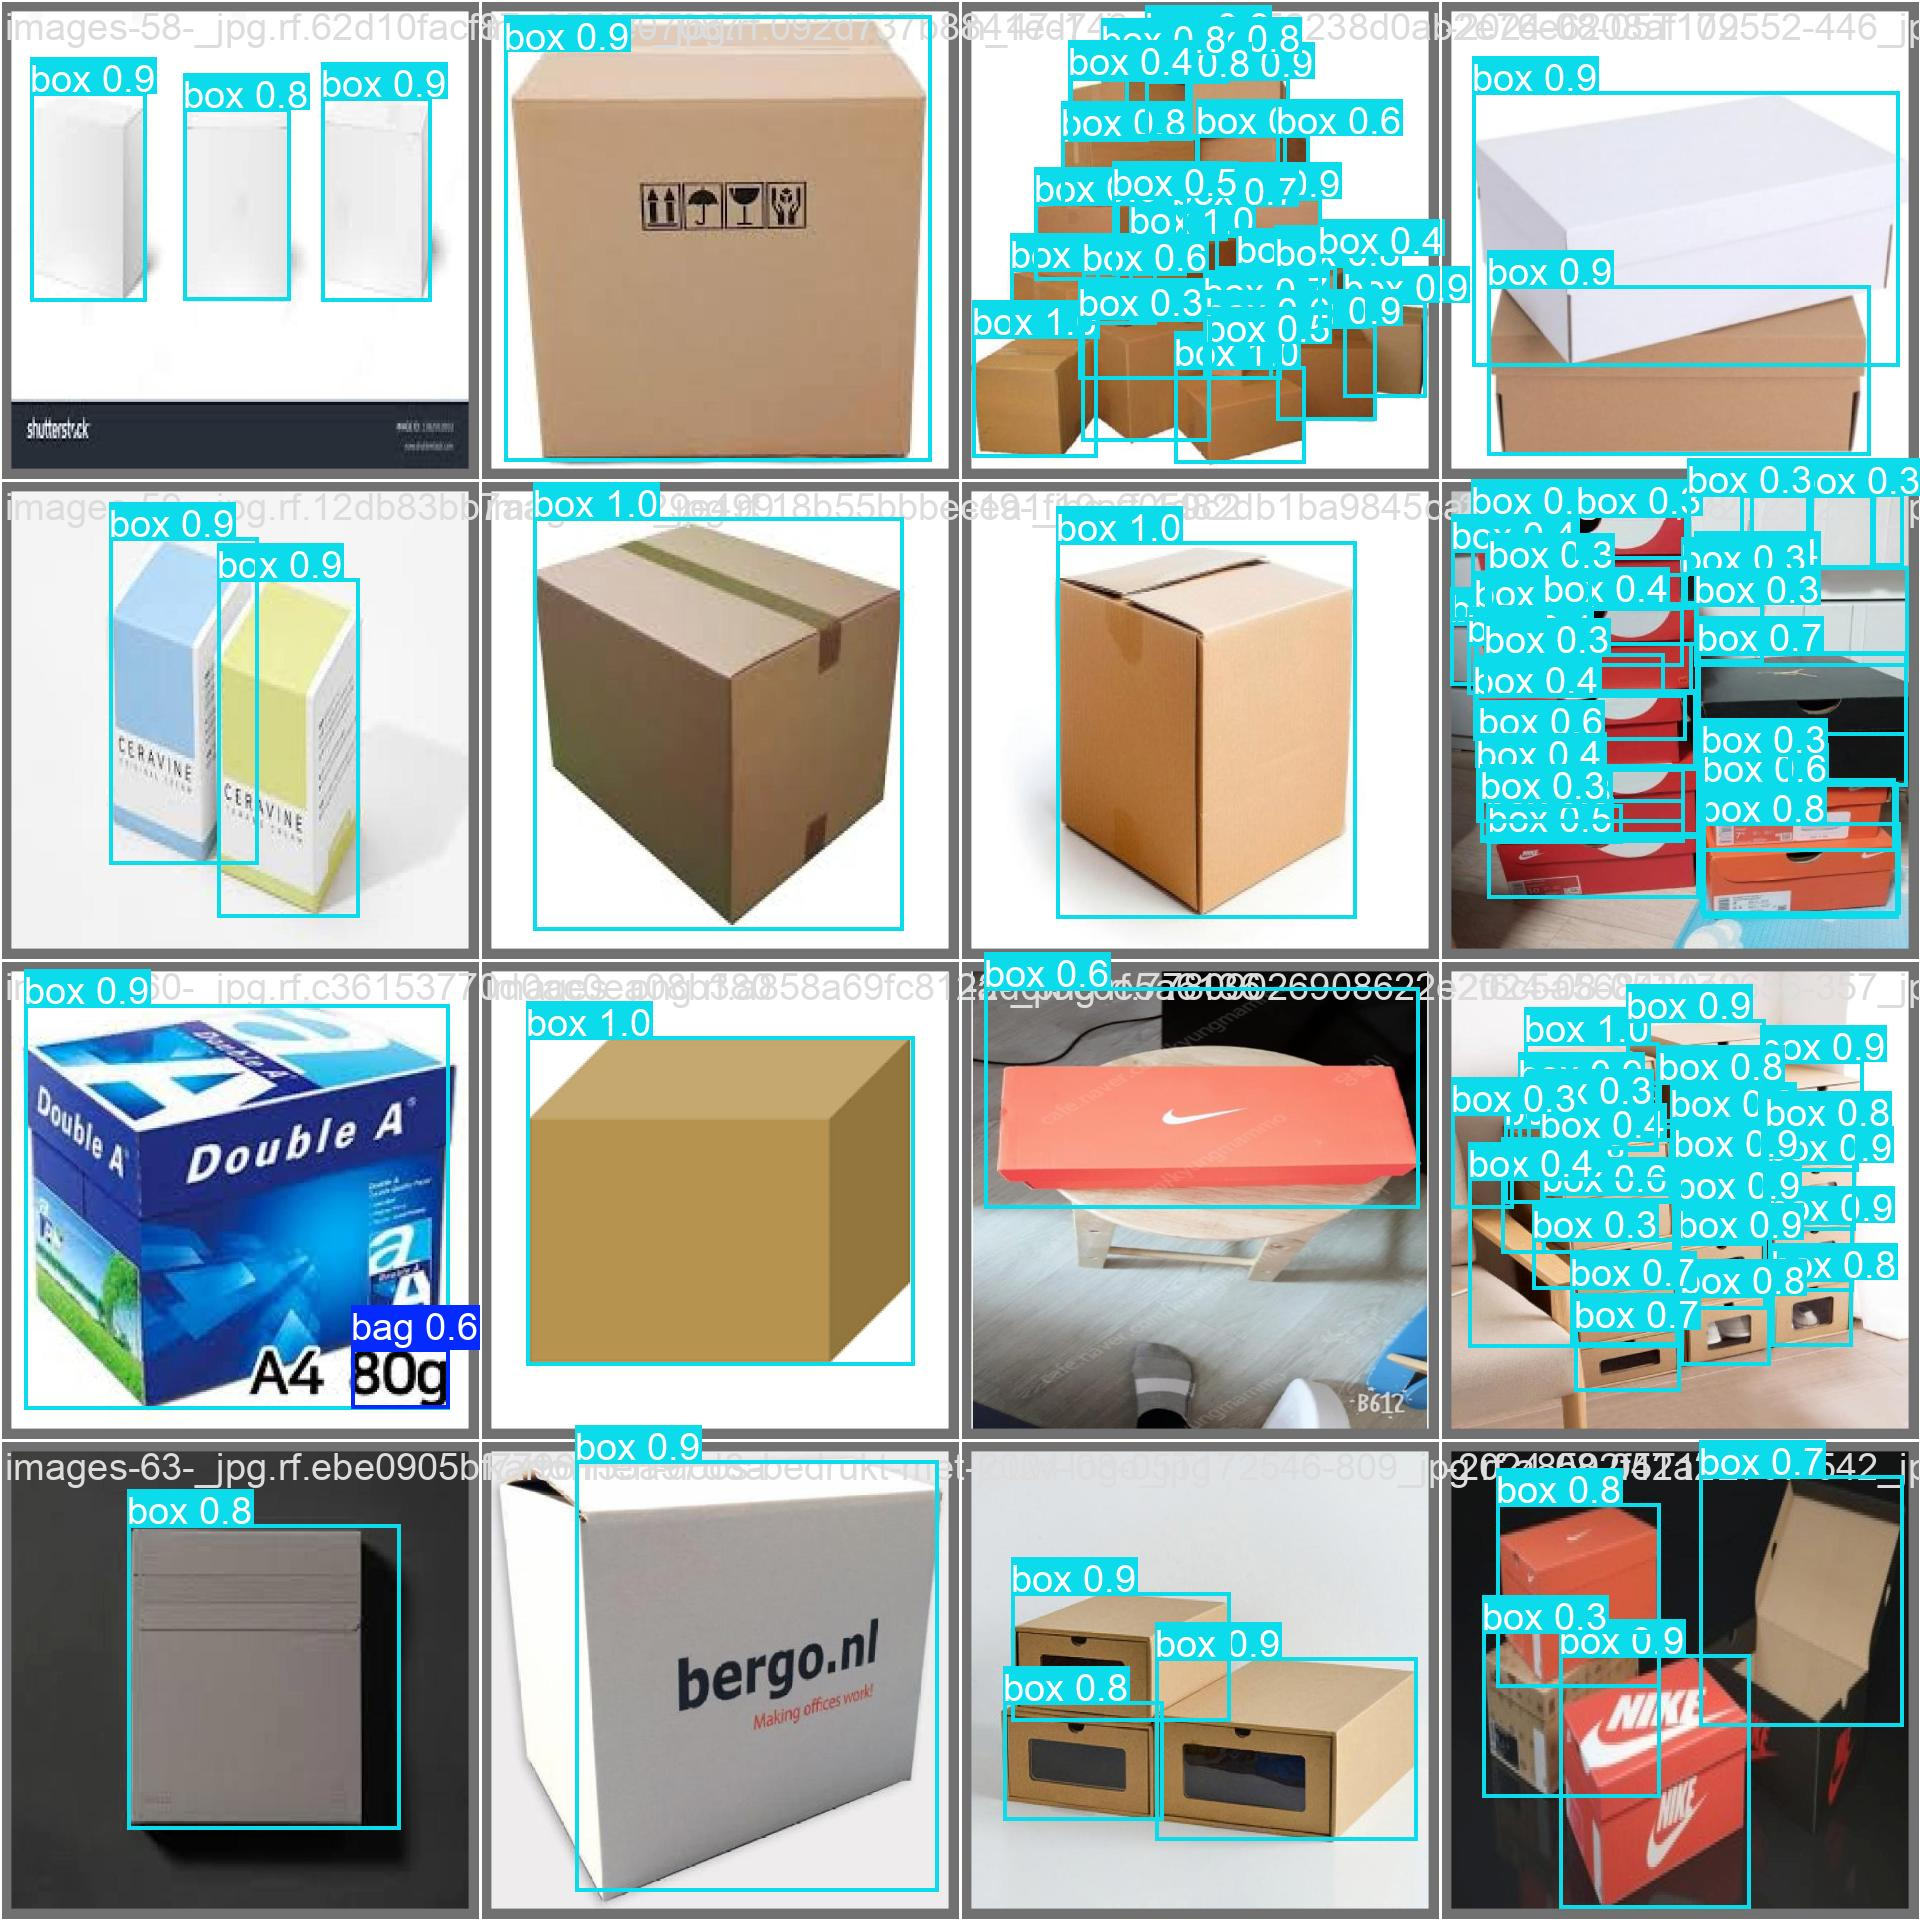

In [13]:
display(Image(filename='YOLO12m-Detection/train_results/val_batch0_pred.jpg'))

# 5. Uji Coba

In [14]:
best_model_path = "YOLO12m-Detection/train_results/weights/best.pt"
loaded_model = YOLO(best_model_path)

In [15]:
import glob
import os
import random

val_image_files = sorted(glob.glob(os.path.join(data_config['val'], '*.jpg')))

if len(val_image_files) >= 3:
    random_val_images = random.sample(val_image_files, 3)
else:
    random_val_images = val_image_files


In [16]:
print("Menjalankan prediksi pada 3 gambar acak dari validation set...")

for image_path in random_val_images:
    print(f"\n--- Prediksi untuk: {os.path.basename(image_path)} ---")
    # Lakukan prediksi
    results = loaded_model.predict(source=image_path, save=False) 
    
    # Dapatkan gambar dengan hasil prediksi
    result_plot = results[0].plot() 
    result_plot_rgb = cv2.cvtColor(result_plot, cv2.COLOR_BGR2RGB)
    
    # Tampilkan gambar
    display(PILImage.fromarray(result_plot_rgb))

Menjalankan prediksi pada 3 gambar acak dari validation set...
